# Desafío 2: Custom Embeddings con Word2Vec
## Análisis de similitud semántica en Viaje al centro de la Tierra de Julio Verne

**Asignatura:** Procesamiento de Lenguaje Natural I (CEIA - FIUBA)

**Autor:** Leandro A. Britez

**Corpus de estudio:** `corpus_JulioVerne.txt`, correspondiente al texto completo de *Viaje al centro de la Tierra* de Julio Verne, con 4.602 líneas.


---

### Introducción y contexto literario

En este cuaderno se desarrolla el **Desafío 2**, utilizando el modelo **Word2Vec (Skip-gram)** de Gensim sobre la obra *Viaje al centro de la Tierra*, de Julio Verne.

El texto combina elementos de aventura, exploración y conocimientos científicos relacionados con la geología, la paleontología y la naturaleza. Esta variedad permite analizar cómo el modelo aprende relaciones entre palabras a partir del contexto en el que aparecen dentro de la obra.

Para realizar el análisis se seleccionaron cinco palabras de interés relacionadas con personajes y elementos importantes de la obra:

1. `profesor`
2. `axel`
3. `hans`
4. `volcán`
5. `tierra`

A partir de estas palabras se analizarán sus términos más y menos similares y se visualizarán los embeddings en dos dimensiones. El objetivo es observar qué relaciones aprende Word2Vec a partir del contexto del texto y analizar si estas relaciones pueden asociarse con las características y situaciones que aparecen en la obra.




In [21]:
# Importación de librerías esenciales
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing & Gensim
import gensim
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from tensorflow.keras.preprocessing.text import text_to_word_sequence


# Dimensionality Reduction & Visualization
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

print(f"Versión de Gensim: {gensim.__version__}")


Versión de Gensim: 4.4.0


## 1. Carga y preprocesamiento del corpus (`corpus_JulioVerne.txt`)

Se carga el texto completo de *Viaje al centro de la Tierra* desde el archivo `corpus_JulioVerne.txt`.

Luego, cada línea del archivo se procesa utilizando `text_to_word_sequence` de Keras. Esta función convierte el texto a minúsculas y separa el contenido en palabras, eliminando los signos de puntuación.

El resultado es una lista de secuencias de palabras que será utilizada posteriormente para entrenar el modelo Word2Vec.



In [27]:
# Carga del archivo de texto
file_path = 'corpus_JulioVerne.txt'

if not os.path.exists(file_path):
    raise FileNotFoundError(f"No se encontró el archivo {file_path}. Verifique la ubicación.")

with open(file_path, 'r', encoding='utf-8') as f:
    raw_lines = f.readlines()

print(f"Número total de líneas leídas: {len(raw_lines)}")

# Tokenización con text_to_word_sequence
sentence_tokens = []
for line in raw_lines:
    line_str = line.strip()
    if line_str:
        tokens = text_to_word_sequence(line_str, filters='!"#$%&()*+,./:;<=>?@[\\]^_`{|}~\t\n-—')
        if len(tokens) > 0:
            sentence_tokens.append(tokens)

total_tokens = sum(len(s) for s in sentence_tokens)
vocabulary_set = set(token for sentence in sentence_tokens for token in sentence)

print(f"Oraciones / párrafos procesados: {len(sentence_tokens)}")
print(f"Total de tokens (palabras): {total_tokens}")
print(f"Tamaño del vocabulario único: {len(vocabulary_set)}")

print("\n--- Muestra de las primeras 3 líneas tokenizadas ---")
for i, s in enumerate(sentence_tokens[:3]):
    print(f"Línea {i+1}: {s}")


Número total de líneas leídas: 4602
Oraciones / párrafos procesados: 2328
Total de tokens (palabras): 70824
Tamaño del vocabulario único: 11282

--- Muestra de las primeras 3 líneas tokenizadas ---
Línea 1: ['capítulo', '1']
Línea 2: ['el', 'domingo', '24', 'de', 'mayo', 'de', '1863', 'mi', 'tío', 'el', 'profesor', 'lidenbrock', 'entró', 'rápidamente', 'a', 'su', 'hogar', 'situado', 'en', 'el', 'número', '19', 'de', 'la', 'könig‑strasse', 'una', 'de', 'las', 'calles', 'más', 'tradicionales', 'del', 'barrio', 'antiguo', 'de', 'hamburgo']
Línea 3: ['marta', 'su', 'excelente', 'criada', 'se', 'preocupó', 'sobremanera', 'creyendo', 'que', 'se', 'había', 'retrasado', 'pues', 'apenas', 'empezaba', 'a', 'cocinar', 'la', 'comida', 'en', 'el', 'hornillo']


## 2. Monitoreo de pérdida con un callback personalizado

Para observar cómo evoluciona el entrenamiento, se crea un callback personalizado a partir de `CallbackAny2Vec` de Gensim.

El callback registra la pérdida (`loss`) al finalizar cada época y calcula la pérdida correspondiente a cada una de ellas. Esto permite seguir la evolución del entrenamiento y verificar si el modelo está aprendiendo de forma adecuada.



In [28]:
class MonitorLossCallback(CallbackAny2Vec):
    '''Registra la pérdida durante el entrenamiento.'''
    def __init__(self):
        self.epoch = 0
        self.losses = []
        self.previous_loss = 0

    def on_epoch_end(self, model):
        current_loss = model.get_latest_training_loss()
        epoch_loss = current_loss - self.previous_loss if self.epoch > 0 else current_loss
        self.previous_loss = current_loss
        self.losses.append(epoch_loss)
        if (self.epoch + 1) % 10 == 0 or self.epoch == 0:
            print(f"Época {self.epoch + 1:3d} | Pérdida de la época: {epoch_loss:.2f}")
        self.epoch += 1


## 3. Entrenamiento del modelo Word2Vec (Skip-gram)

Se entrena un modelo `Word2Vec` utilizando la arquitectura **Skip-gram** (`sg=1`). Esta configuración permite aprender representaciones de las palabras a partir de los términos que aparecen cerca de ellas en el texto.

Para este experimento se utilizan los siguientes parámetros:

* **`vector_size = 100`**: cada palabra se representa mediante un vector de 100 dimensiones.
* **`window = 10`**: el modelo considera hasta 10 palabras de contexto a cada lado de la palabra analizada. Se utiliza una ventana relativamente amplia para capturar relaciones que puedan aparecer a lo largo de las descripciones, diálogos y situaciones de la obra.
* **`min_count = 5`**: se consideran las palabras que aparecen al menos cinco veces en el corpus. Esto permite reducir la presencia de palabras muy poco frecuentes, cuyos vectores pueden ser menos representativos.
* **`sg = 1`**: utiliza la arquitectura Skip-gram, siguiendo el enfoque trabajado en clase.
* **`negative = 20`**: se utiliza negative sampling con 20 ejemplos negativos, siguiendo la configuración presentada en clase.
* **`workers = 4`**: utiliza cuatro hilos para realizar el entrenamiento.
* **`epochs = 80`**: se realizan 80 pasadas sobre el corpus para darle al modelo varias oportunidades de aprender las relaciones entre las palabras.

Se utiliza además una semilla (`seed=42`) para facilitar la reproducción de los resultados.

### Configuración elegida

Los parámetros se definieron teniendo en cuenta el tamaño del corpus y el objetivo del experimento. Al tratarse de una obra literaria, se busca que el modelo pueda captar relaciones entre palabras que aparecen dentro de un contexto relativamente amplio.

Por este motivo, se utiliza una ventana de `10` palabras en lugar de una ventana más pequeña. A su vez, `min_count=5` permite trabajar con un vocabulario más representativo y evitar que palabras con muy pocas apariciones influyan demasiado en los resultados.

La dimensión de los vectores se establece en `100`, buscando un equilibrio entre la cantidad de información que puede representar cada palabra y el tamaño relativamente acotado del corpus.

La cantidad de épocas se establece inicialmente en `80`. Esta elección se realiza como parte del experimento y posteriormente se observa la evolución de la pérdida para evaluar el comportamiento del entrenamiento.

Luego del entrenamiento se grafica la pérdida (`loss`) registrada en cada época para observar cómo evoluciona el proceso de aprendizaje.




Vocabulario construido en el modelo: 1718 palabras.

--- Iniciando entrenamiento ---
Época   1 | Pérdida de la época: 390251.00
Época  10 | Pérdida de la época: 267709.50
Época  20 | Pérdida de la época: 236265.00
Época  30 | Pérdida de la época: 239007.50
Época  40 | Pérdida de la época: 221495.00
Época  50 | Pérdida de la época: 216118.00
Época  60 | Pérdida de la época: 213669.00
Época  70 | Pérdida de la época: 217026.00
Época  80 | Pérdida de la época: 216812.00
--- Entrenamiento finalizado ---



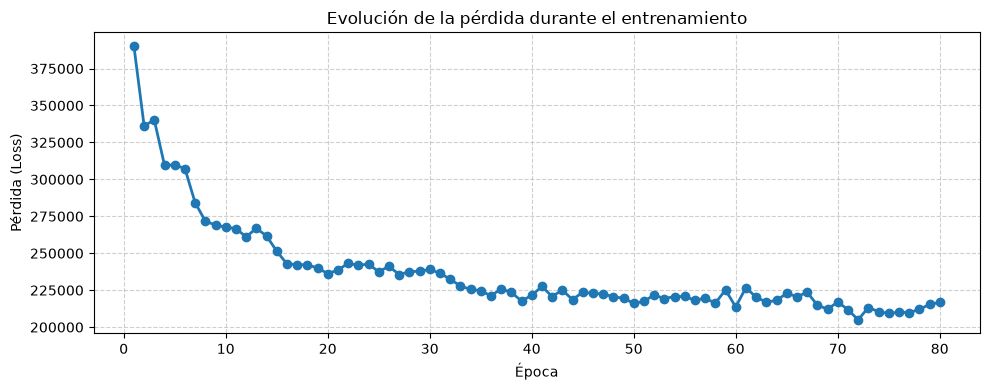

In [29]:
# Instanciamos el callback
monitor_callback = MonitorLossCallback()

# Instanciación del modelo Word2Vec
model = Word2Vec(
    vector_size=100,
    window=10,
    min_count=5,
    negative=20,
    sg=1,              # Skip-gram
    workers=4,
    seed=42
)

# Construcción del vocabulario
model.build_vocab(sentence_tokens)

vocab_size = len(model.wv)
print(f"Vocabulario construido en el modelo: {vocab_size} palabras.")

# Entrenamiento del modelo
print("\n--- Iniciando entrenamiento ---")

model.train(
    sentence_tokens,
    total_examples=model.corpus_count,
    epochs=80,
    compute_loss=True,
    callbacks=[monitor_callback]
)

print("--- Entrenamiento finalizado ---\n")

# Graficar la evolución de la pérdida
plt.figure(figsize=(10, 4))

plt.plot(
    range(1, len(monitor_callback.losses) + 1),
    monitor_callback.losses,
    marker='o',
    linewidth=2
)

plt.title('Evolución de la pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Análisis de similitud semántica para las palabras objetivo

Se analizan las palabras `profesor`, `axel`, `hans`, `volcán` y `tierra` utilizando `model.wv.most_similar()`.

Esta función permite obtener las palabras cuyos vectores se encuentran más próximos al vector de cada palabra objetivo, utilizando la **similitud de coseno** como medida.

Para cada palabra se muestran los 8 términos más similares junto con su valor de similitud. Los resultados se analizarán teniendo en cuenta el contexto de la obra y las relaciones que el modelo aprendió a partir del corpus.




In [30]:
target_words = ['profesor', 'axel', 'hans', 'volcán', 'tierra']

results_dict = {}

for word in target_words:
    if word in model.wv:
        similars = model.wv.most_similar(word, topn=8)
        results_dict[word] = similars
        print(f"=== Palabra Clave: '{word.upper()}' ===")
        df_sim = pd.DataFrame(similars, columns=['Palabra Vecina', 'Similitud Coseno'])
        print(df_sim.to_string(index=False))
        print("-" * 50)
    else:
        print(f"La palabra '{word}' no se encuentra en el vocabulario.")


=== Palabra Clave: 'PROFESOR' ===
Palabra Vecina  Similitud Coseno
    lidenbrock          0.593839
           tío          0.589443
            el          0.505478
          otto          0.475888
            me          0.469254
             a          0.464928
           que          0.463845
           con          0.462516
--------------------------------------------------
=== Palabra Clave: 'AXEL' ===
Palabra Vecina  Similitud Coseno
       querido          0.534309
            tu          0.499867
            te          0.478553
         ¡mira          0.476841
          hijo          0.473260
           ves          0.448713
         usted          0.435746
          eres          0.429459
--------------------------------------------------
=== Palabra Clave: 'HANS' ===
Palabra Vecina  Similitud Coseno
           con          0.440376
      marchaba          0.425957
  indiferencia          0.419186
       decidió          0.416153
             a          0.408721
            

### Interpretación de los resultados

En `profesor` aparece `lidenbrock` como principal vecino y también `tío`, relaciones que tienen sentido dentro de la obra, ya que Lidenbrock es el tío de Axel y es referido como profesor.

En `volcán` aparecen `cumbre`, `sneffels`, `cráter` y `chimenea`, términos relacionados con las características y descripciones de los volcanes presentes en el viaje.

Para `tierra`, `superficie`, `globo` y `mundo` aparecen entre los términos más cercanos, mostrando diferentes conceptos asociados a la palabra dentro del corpus.

En `axel` y `hans` aparecen principalmente palabras vinculadas con diálogos y acciones, aunque las relaciones son menos evidentes. Esto muestra que Word2Vec aprende a partir del contexto en el que aparecen las palabras y no necesariamente produce sinónimos o características directas.

Algunos resultados presentan relaciones claras con el contenido de la obra, mientras que otros requieren analizar el contexto para poder interpretarlos.





## 5. Análisis de términos menos similares

Luego de obtener los términos más similares para cada palabra objetivo, se busca también identificar aquellos que presentan menor similitud.

Para esto se calcula la similitud de coseno entre cada palabra objetivo y las palabras del vocabulario del modelo. Los resultados se ordenan de menor a mayor y se muestran los cinco términos menos similares.

Este análisis permite complementar los resultados anteriores y observar qué palabras presentan una menor relación con cada término dentro del contexto aprendido por Word2Vec.




In [32]:
# Análisis de los términos menos similares

for word in target_words:
    if word in model.wv:
        
        # Obtener todas las palabras del vocabulario
        words = model.wv.index_to_key
        
        # Calcular similitud con todas las palabras
        similarities = [
            (other_word, model.wv.similarity(word, other_word))
            for other_word in words
            if other_word != word
        ]
        
        # Ordenar de menor a mayor similitud
        least_similar = sorted(similarities, key=lambda x: x[1])[:5]
        
        print(f"=== Palabra Clave: '{word.upper()}' ===")
        
        df_least = pd.DataFrame(
            least_similar,
            columns=['Palabra Vecina', 'Similitud Coseno']
        )
        
        print(df_least.to_string(index=False))
        print("-" * 50)

=== Palabra Clave: 'PROFESOR' ===
Palabra Vecina  Similitud Coseno
       bóvedas         -0.094189
     inclinaba         -0.076705
         color         -0.072147
        humano         -0.070256
         acaba         -0.058440
--------------------------------------------------
=== Palabra Clave: 'AXEL' ===
Palabra Vecina  Similitud Coseno
      uniforme         -0.119885
      permitía         -0.094617
       paredes         -0.078379
      corredor         -0.072852
      abertura         -0.072460
--------------------------------------------------
=== Palabra Clave: 'HANS' ===
Palabra Vecina  Similitud Coseno
 absolutamente         -0.093147
         seres         -0.076039
      inmensas         -0.065979
          davy         -0.065867
     fenómenos         -0.063170
--------------------------------------------------
=== Palabra Clave: 'VOLCÁN' ===
Palabra Vecina  Similitud Coseno
       hablaba         -0.101919
     excelente         -0.099823
      escribir         -0.09

### Interpretación de los resultados

Los términos obtenidos presentan valores de similitud bajos o negativos con respecto a las palabras objetivo. Esto indica que se encuentran alejados en el espacio de representación aprendido por el modelo.

No se interpretan como antónimos, sino simplemente como palabras que presentan poca relación contextual con cada término dentro del corpus. Las asociaciones encontradas varían entre las distintas palabras y no muestran, en principio, un patrón semántico claro.


## 6. Reducción de Dimensionalidad y Visualizaciones Interactivas (t-SNE & Plotly)

Para visualizar los embeddings en un espacio de menor dimensión se utiliza t-SNE (t-Distributed Stochastic Neighbor Embedding). Esta técnica permite proyectar los vectores de las palabras a un espacio de 2 y 3 dimensiones, facilitando la observación de relaciones y posibles agrupamientos entre ellas.

Para evitar una visualización excesivamente cargada, se seleccionan las palabras más frecuentes del vocabulario mediante el parámetro MAX_WORDS. Al mismo tiempo, se asegura la inclusión de las cinco palabras objetivo: profesor, axel, hans, volcán y tierra.

Las visualizaciones se realizan de forma interactiva utilizando Plotly, lo que permite explorar la posición de las palabras y observar distintos agrupamientos dentro del espacio generado.



### 6.1. Proyección t-SNE en 2 dimensiones

Primero se realiza una reducción a dos dimensiones. Se utiliza MAX_WORDS = 250 para obtener una representación que permita observar los agrupamientos sin sobrecargar excesivamente el gráfico.

In [34]:
vocab_words = list(model.wv.key_to_index.keys())

MAX_WORDS = 250

top_n = min(MAX_WORDS, len(vocab_words))
words_to_plot = vocab_words[:top_n]

# Asegurar que las palabras objetivo estén incluidas
for tw in target_words:
    if tw in model.wv and tw not in words_to_plot:
        words_to_plot.append(tw)

vectors = np.array([model.wv[w] for w in words_to_plot])

# t-SNE 2D
tsne_2d = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, len(words_to_plot) - 1),
    max_iter=1000
)

coords_2d = tsne_2d.fit_transform(vectors)

df_2d = pd.DataFrame({
    'word': words_to_plot,
    'x': coords_2d[:, 0],
    'y': coords_2d[:, 1],
    'is_target': [w in target_words for w in words_to_plot]
})

df_2d['color'] = df_2d['is_target'].map({
    True: 'Palabra Clave (Objetivo)',
    False: 'Otras Palabras del Corpus'
})

df_2d['size'] = df_2d['is_target'].map({
    True: 16,
    False: 8
})

fig_2d = px.scatter(
    df_2d,
    x='x',
    y='y',
    text='word',
    color='color',
    size='size',
    color_discrete_map={
        'Palabra Clave (Objetivo)': '#e74c3c',
        'Otras Palabras del Corpus': '#2980b9'
    },
    title='<b>Visualización t-SNE 2D de Custom Embeddings - Julio Verne</b>',
    labels={
        'x': 'Dimensión t-SNE 1',
        'y': 'Dimensión t-SNE 2'
    }
)

fig_2d.update_traces(
    textposition='top center',
    marker=dict(opacity=0.85)
)

fig_2d.update_layout(
    height=750,
    width=1000,
    template='plotly_white',
    legend_title_text='Categoría'
)

fig_2d.show()


### RESULTADO

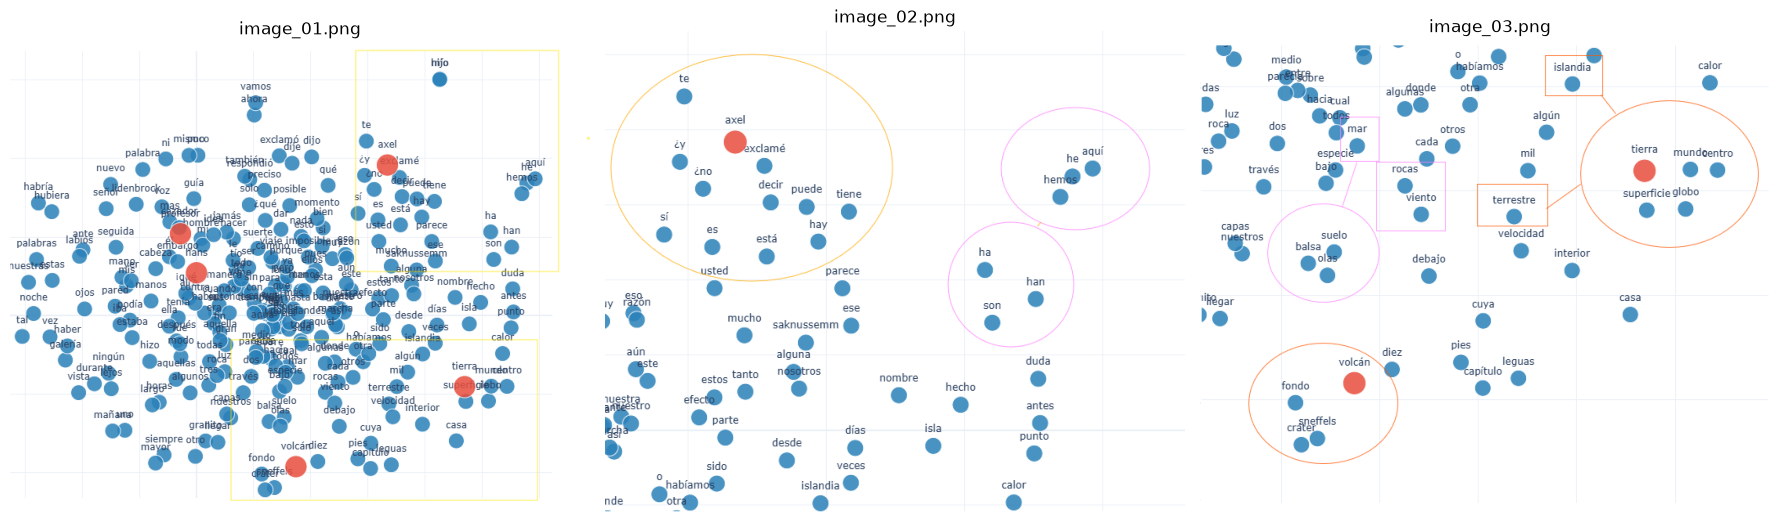

In [38]:
from PIL import Image
import matplotlib.pyplot as plt

files = ['image_01.png', 'image_02.png', 'image_03.png']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, file in zip(axes, files):
    img = Image.open(file)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(file)

plt.tight_layout()
plt.show()

#### Observación general

La proyección general permite identificar diferentes agrupamientos dentro del espacio de embeddings. Se seleccionaron algunos sectores para analizar con mayor detalle.

##### Caso 1: axel

Uno de los primeros casos observados corresponde a la palabra axel. En la proyección 2D aparece relativamente aislada respecto de otras palabras que permitan establecer una relación semántica clara. Entre sus términos cercanos aparecen palabras como exclamé, te, ¿y? y ¿no?.

Este resultado no permite identificar una característica concreta del personaje. Sin embargo, muestra que la representación aprendida para axel está relacionada con expresiones frecuentes de los diálogos en los que aparece el personaje.

##### Caso 2: agrupamiento de formas verbales

En otra zona del gráfico se observa un pequeño agrupamiento formado por términos como: 'aquí, he, hemos, ha, han y son'.

Este agrupamiento no presenta una relación temática evidente. Las palabras comparten principalmente características de uso dentro de la construcción de frases y aparecen en contextos narrativos y descriptivos similares.

##### Caso 3: volcán

Entre los términos cercanos aparecen: 'cráter, sneffels, fondo y diez'. Particularmente, la proximidad entre volcán, cráter y sneffels resulta significativa dentro del contexto de la obra. Sneffels es el volcán relacionado con el inicio de la expedición, mientras que el cráter constituye un elemento directamente asociado con su descripción.

##### Caso 4: tierra

Otro resultado destacable corresponde a tierra, que aparece próxima a 'mundo, centro, superficie, globo y terrestre'.

Este agrupamiento presenta una relación conceptual clara. Las palabras están asociadas con distintas formas de describir la Tierra y sus características, y además se relacionan directamente con uno de los conceptos centrales de la obra.

Este resultado es consistente con el análisis de similitud realizado anteriormente, donde superficie, globo y mundo también aparecían entre los términos más similares a tierra.

##### Caso 5: agrupamiento relacionado con el entorno

También se observa un pequeño grupo formado por: 'balsa, suelo, olas y mar'.

Es interesante porque varias palabras pertenecen a un contexto asociado con la navegación. La presencia de mar en las proximidades refuerza esta idea. Aquí sí puede observarse una relación temática más clara entre los términos.

### 6.2. Proyección t-SNE en 3 dimensiones

Como complemento de la visualización anterior, se realiza una segunda reducción utilizando tres dimensiones. Se mantienen los mismos vectores y la misma configuración general de t-SNE, modificando únicamente la cantidad de dimensiones de salida.

In [36]:
# t-SNE 3D
tsne_3d = TSNE(
    n_components=3,
    random_state=42,
    perplexity=min(30, len(words_to_plot) - 1),
    max_iter=1000
)

coords_3d = tsne_3d.fit_transform(vectors)

df_3d = pd.DataFrame({
    'word': words_to_plot,
    'x': coords_3d[:, 0],
    'y': coords_3d[:, 1],
    'z': coords_3d[:, 2],
    'is_target': [w in target_words for w in words_to_plot]
})

df_3d['color'] = df_3d['is_target'].map({
    True: 'Palabra Clave',
    False: 'Corpus'
})

df_3d['size'] = df_3d['is_target'].map({
    True: 10,
    False: 4
})

fig_3d = px.scatter_3d(
    df_3d,
    x='x',
    y='y',
    z='z',
    text='word',
    color='color',
    size='size',
    color_discrete_map={
        'Palabra Clave': '#e74c3c',
        'Corpus': '#16a085'
    },
    title='<b>Proyección 3D t-SNE del Espacio Latente (Julio Verne)</b>'
)

fig_3d.update_traces(marker=dict(opacity=0.8))

fig_3d.update_layout(
    height=800,
    width=1000,
    template='plotly_dark'
)

fig_3d.show()

### Resultados

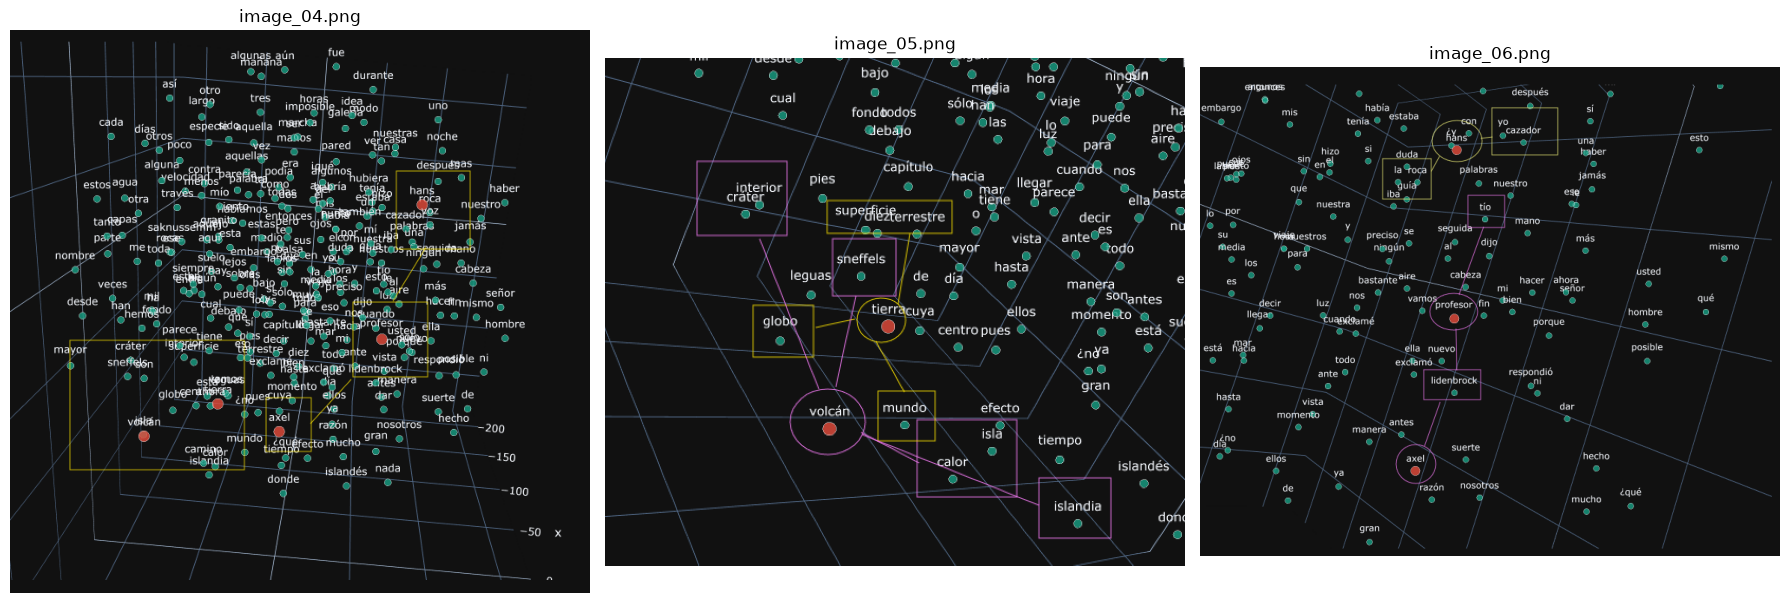

In [39]:
from PIL import Image
import matplotlib.pyplot as plt

files = ['image_04.png', 'image_05.png', 'image_06.png']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, file in zip(axes, files):
    img = Image.open(file)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(file)

plt.tight_layout()
plt.show()

La representación 3D presenta una distribución más dispersa y resulta más difícil identificar agrupamientos de manera inmediata que en la representación 2D. Sin embargo, al explorar distintas zonas de la visualización pueden observarse relaciones interesantes entre algunas de las palabras objetivo.

### Relación entre tierra y volcán

Se observa una proximidad entre tierra y volcán. En su entorno aparecen términos como:

globo, centro, superficie, interior, terrestre, sneffels, cráter, leguas y pies.

Algunos términos aparecen relacionados con ambas palabras. Por ejemplo, sneffels se encuentra próximo tanto al entorno de volcán como al de tierra, mientras que globo, superficie, interior y terrestre refuerzan principalmente el contexto asociado con tierra.

### Relación entre personajes

En esta zona se observa la proximidad entre axel y profesor. Alrededor de profesor aparecen lidenbrock y tío, lo cual resulta especialmente significativo dentro del contexto de la obra. 

También aparece hans asociado a palabras como cazador y roca. En este caso, la relación permite vincular al personaje con características y elementos de su contexto dentro de la historia.

Este comportamiento no se había observado con tanta claridad en la proyección 2D y constituye uno de los ejemplos donde la representación 3D aporta una perspectiva complementaria.

## 7. Conclusiones

El modelo logró aprender algunas relaciones coherentes con el contexto de Viaje al centro de la Tierra, especialmente en términos como volcán, cráter, sneffels y tierra, superficie, globo y mundo. La visualización también permitió encontrar agrupamientos no definidos previamente, algunos relacionados con contextos temáticos y otros con patrones de uso del lenguaje.

Una de las principales limitaciones es que el corpus está compuesto por una única obra, por lo que los embeddings representan principalmente las relaciones presentes dentro de ese libro. Además, algunas relaciones pueden depender de un contexto narrativo más amplio, incluso entre distintos capítulos, que una ventana local de palabras no logra representar completamente.

Finalmente, el preprocesamiento podría mejorarse eliminando palabras muy frecuentes y de poca carga semántica, como algunos conectores y palabras funcionales. Esto podría reducir agrupamientos dominados por su frecuencia y permitir observar con mayor claridad las relaciones entre conceptos relevantes.